In [1]:
import sqlite3, pandas as pd

PAIR_META = {
    "btc100k_dec2026": {"theta": 0.07, "resolves": "2026-12-31"},
    "btc100k_sep2026": {"theta": 0.07, "resolves": "2026-09-30"},
    "eth_sep_3000":    {"theta": 0.07, "resolves": "2026-09-30"},
    "fed_cuts_0":      {"theta": 0.05, "resolves": "2026-12-31"},
    "fed_cuts_1":      {"theta": 0.05, "resolves": "2026-12-31"},
    "fed_cuts_2":      {"theta": 0.05, "resolves": "2026-12-31"},
}

def load_quotes(db="crossvenue.db"):
    c = sqlite3.connect(db)
    q = pd.read_sql("SELECT * FROM quotes", c)
    q["ts"] = pd.to_datetime(q["ts"])
    for col in ["best_bid", "best_ask", "bid_size", "ask_size"]:
        q[col] = pd.to_numeric(q[col], errors="coerce")
    return q

def analyse_pair(q, pair, theta_poly, resolves, tolerance="30s"):
    sel = lambda v, a, b: (q[(q.pair_id == pair) & (q.venue == v)].sort_values("ts")
                           [["ts", "best_bid", "best_ask"]]
                           .rename(columns={"best_bid": a, "best_ask": b}))
    k, p = sel("kalshi", "k_bid", "k_ask"), sel("poly", "p_bid", "p_ask")
    if k.empty or p.empty:
        return pd.DataFrame()

    m = pd.merge_asof(k, p, on="ts", direction="backward",
                      tolerance=pd.Timedelta(tolerance)).dropna(subset=["p_bid", "p_ask"])
    if m.empty:
        return m

    m["pair_id"]  = pair
    m["mid_k"]    = (m.k_bid + m.k_ask) / 2
    m["mid_p"]    = (m.p_bid + m.p_ask) / 2
    m["gap_mid"]  = m.mid_k - m.mid_p
    m["gap_exec"] = pd.concat([m.k_bid - m.p_ask,
                               m.p_bid - m.k_ask], axis=1).max(axis=1).clip(lower=0)

    m["net_exec"] = (m.gap_exec
                     - 0.07       * m.mid_k * (1 - m.mid_k)
                     - theta_poly * m.mid_p * (1 - m.mid_p))

    res = pd.Timestamp(resolves + " 23:59:59", tz=m.ts.dt.tz)
    m["days"] = (res - m.ts).dt.total_seconds() / 86400
    m["ann_return"] = (m.net_exec / (1 - m.gap_exec)) * (365 / m["days"])
    return m

def summarise(m):
    if m.empty:
        return None
    prof = m[m.net_exec > 0]
    return {
        "pair":          m.pair_id.iloc[0],
        "n":             len(m),
        "hours":         round((m.ts.max() - m.ts.min()).total_seconds() / 3600, 1),
        "crossing_%":    round((m.gap_exec > 0).mean() * 100, 2),
        "profitable_%":  round((m.net_exec > 0).mean() * 100, 2),
        "median_ann_%":  round(prof.ann_return.median() * 100, 3) if len(prof) else None,
        "max_ann_%":     round(prof.ann_return.max()    * 100, 3) if len(prof) else None,
    }

q = load_quotes()
results = {p: analyse_pair(q, p, mm["theta"], mm["resolves"]) for p, mm in PAIR_META.items()}
pd.DataFrame([r for r in (summarise(v) for v in results.values()) if r])

,pair,n,hours,crossing_%,profitable_%,median_ann_%,max_ann_%
0,btc100k_dec2026,23199,148.4,32.35,7.89,3.380,14.028
1,btc100k_sep2026,23199,148.4,9.38,6.46,1.343,58.812
2,eth_sep_3000,19073,125.5,16.65,3.23,8.531,117.802
3,fed_cuts_0,19075,125.5,57.99,21.55,0.537,2.137
4,fed_cuts_1,19075,125.5,99.64,97.52,5.271,12.670
5,fed_cuts_2,19075,125.5,52.98,52.98,1.399,5.831


In [2]:
import sqlite3, pandas as pd

c = sqlite3.connect("crossvenue.db")
h = pd.read_sql("SELECT ts, venue, pair_id FROM quotes WHERE pair_id='btc100k_dec2026'", c)
h["ts"] = pd.to_datetime(h["ts"])
h = h.sort_values(["venue", "ts"])
h["gap_min"] = h.groupby("venue")["ts"].diff().dt.total_seconds() / 60

print(h.groupby("venue").agg(n=("ts", "size"), first=("ts", "min"), last=("ts", "max")))
print("\nGaps longer than 5 minutes:")
print(h[h.gap_min > 5][["venue", "ts", "gap_min"]])

            n                     first                      last
venue                                                            
kalshi  23200 2026-09-16 15:00:24+00:00 2026-09-22 19:26:35+00:00
poly    23455 2026-09-16 15:00:24+00:00 2026-09-22 19:26:35+00:00

Gaps longer than 5 minutes:
        venue                        ts  gap_min
10145  kalshi 2026-09-18 13:16:44+00:00  1078.15
10146    poly 2026-09-18 13:16:44+00:00  1078.15


In [3]:
import requests
HEADERS = {"User-Agent": "crossvenue-research/0.1"}

k = requests.get("https://external-api.kalshi.com/trade-api/v2/markets/"
                 "KXRATECUTCOUNT-26DEC31-T1", timeout=15, headers=HEADERS).json()["market"]
print("=== KALSHI ===")
print(k.get("rules_primary", "")[:1500])

ev = requests.get("https://gamma-api.polymarket.com/events?slug=how-many-fed-rate-cuts-in-2026",
                  timeout=15).json()
pm = [m for m in ev[0]["markets"] if "Will 1 Fed rate cut happen" in m["question"]][0]
print("\n=== POLYMARKET ===")
print(pm.get("description", "")[:1500])

=== KALSHI ===
If the Fed cuts 1 times starting Jan 1, 2026 and before 2027, then the market resolves to Yes.

=== POLYMARKET ===
This market will resolve according to the exact amount of cuts of 25 basis points in 2026 by the Fed (including any cuts made during the December meeting).

Emergency rate cuts outside of scheduled FOMC meetings will also count toward the total number of cuts in 2026. This market will remain open until December 31, 2026, 11:59 PM ET, to account for any such emergency actions.

For example, if the Fed cuts rates by 50 bps after a meeting, it would be considered 2 cuts (of 25 bps each).

This market will resolve early to "No" if the specified number of cuts becomes impossible — i.e., if more cuts have already occurred than the strike in question.

Note that cuts between 1–24 bps (inclusive) will also be considered 1 rate cut.

The resolution source for this market will be FOMC statements after meetings scheduled in 2026 according to the official calendar: http

In [4]:
print(k.get("rules_secondary", "")[:2000])

To be clear, 25bp of cuts is equal to one cut (so 25bp cut is 1, 50bp cut is 2, 75bp cut is 3, and so on).


In [5]:
import numpy as np

def with_size(q, pair, theta_poly):
    cols = ["ts", "best_bid", "best_ask", "bid_size", "ask_size"]
    def sel(v, p):
        return (q[(q.pair_id == pair) & (q.venue == v)].sort_values("ts")[cols]
                .rename(columns={"best_bid": p+"bid", "best_ask": p+"ask",
                                 "bid_size": p+"bsz", "ask_size": p+"asz"}))
    m = pd.merge_asof(sel("kalshi", "k_"), sel("poly", "p_"), on="ts",
                      direction="backward", tolerance=pd.Timedelta("30s")).dropna()
    a = m.k_bid - m.p_ask      # sell YES on Kalshi, buy YES on Polymarket
    b = m.p_bid - m.k_ask      # sell YES on Polymarket, buy YES on Kalshi
    m["gap_exec"] = np.maximum(np.maximum(a, b), 0)
    m["size"]     = np.where(a >= b, np.minimum(m.k_bsz, m.p_asz),
                                     np.minimum(m.p_bsz, m.k_asz))
    mk, mp = (m.k_bid + m.k_ask) / 2, (m.p_bid + m.p_ask) / 2
    m["net_exec"] = m.gap_exec - 0.07*mk*(1-mk) - theta_poly*mp*(1-mp)
    m["profit_$"] = m.net_exec.clip(lower=0) * m["size"]
    return m

rows = []
for p, mm in PAIR_META.items():
    m = with_size(q, p, mm["theta"])
    prof = m[m.net_exec > 0]
    rows.append({"pair": p,
                 "profitable_%":    round(len(prof) / len(m) * 100, 1),
                 "median_size":     round(prof["size"].median()) if len(prof) else 0,
                 "median_profit_$": round(prof["profit_$"].median(), 2) if len(prof) else 0,
                 "max_profit_$":    round(prof["profit_$"].max(), 2) if len(prof) else 0})
pd.DataFrame(rows)

,pair,profitable_%,median_size,median_profit_$,max_profit_$
0,btc100k_dec2026,7.9,43,0.57,5.09
1,btc100k_sep2026,6.5,10,0.00,3.86
2,eth_sep_3000,3.2,6,0.02,10.18
3,fed_cuts_0,21.5,153,0.09,2.78
4,fed_cuts_1,97.5,28,0.38,66.88
5,fed_cuts_2,53.0,20,0.06,52.21


In [6]:
import requests
HEADERS = {"User-Agent": "crossvenue-research/0.1"}
KAL = "https://external-api.kalshi.com/trade-api/v2/markets/"

def kalshi_rules(ticker):
    m = requests.get(KAL + ticker, timeout=15, headers=HEADERS).json()["market"]
    return m.get("rules_primary", ""), m.get("rules_secondary", "")

def poly_rules(slug, text):
    ev = requests.get(f"https://gamma-api.polymarket.com/events?slug={slug}", timeout=15).json()
    m = [x for x in ev[0]["markets"] if text in x["question"]][0]
    return m["question"], m.get("description", "")

checks = [
    ("btc100k_dec2026", "KXBTCMAX100-26-DEC", "when-will-bitcoin-hit-100k", "December 31, 2026"),
    ("btc100k_sep2026", "KXBTCMAX100-26-SEP", "when-will-bitcoin-hit-100k", "September 30, 2026"),
    ("eth_sep_3000", "KXETHMAXMON-ETH-26SEP30-300000",
     "what-price-will-ethereum-hit-in-september-2026", "reach $3,000"),
]

for pid, kt, slug, text in checks:
    kp, ks = kalshi_rules(kt)
    pq, pdesc = poly_rules(slug, text)
    print("=" * 90, "\n", pid)
    print("\n--- KALSHI primary ---\n", kp[:1200])
    print("\n--- KALSHI secondary ---\n", ks[:1500])
    print(f"\n--- POLYMARKET: {pq} ---\n", pdesc[:1800])

 btc100k_dec2026

--- KALSHI primary ---
 If the Bitcoin spot price according to the CF Bitcoin Real-Time Index is above $100000.00 starting 02/17/2026 04:00 PM and before Jan 1, 2027 at 12:00AM ET, then the market resolves to Yes.

--- KALSHI secondary ---
 The market resolves based on the CF Bitcoin Real-Time Index (BRTI) using a trimmed mean calculation. The resolution value is calculated by taking all BRTI values for each minute from market issuance until the specified time on the target date, removing the top 20% and bottom 20% of values, then averaging the remaining 60% of values. If the BRTI crosses the threshold at any point during the measurement period (triggering early expiration), the market immediately resolves. If no data is available at the expiration time, the market resolves to No. The market can resolve early if Bitcoin definitively crosses the threshold before the target date and time.

--- POLYMARKET: Will Bitcoin hit $100k by December 31, 2026? ---
 This market wil

In [7]:
rows = []
for p, m in results.items():
    prof = m[m.net_exec > 0]
    a = prof.k_bid - prof.p_ask   # > 0: sell YES on Kalshi, buy YES on Polymarket
    b = prof.p_bid - prof.k_ask   # > 0: sell YES on Polymarket, buy YES on Kalshi
    n = max(len(prof), 1)
    rows.append({"pair": p,
                 "profitable_rows": len(prof),
                 "sell_kalshi_%": round((a > 0).sum() / n * 100, 1),
                 "sell_poly_%":   round((b > 0).sum() / n * 100, 1)})
pd.DataFrame(rows)

,pair,profitable_rows,sell_kalshi_%,sell_poly_%
0,btc100k_dec2026,1830,51.7,48.3
1,btc100k_sep2026,1499,80.7,19.3
2,eth_sep_3000,616,10.6,89.4
3,fed_cuts_0,4110,3.4,96.6
4,fed_cuts_1,18601,100.0,0.0
5,fed_cuts_2,10105,99.1,0.9


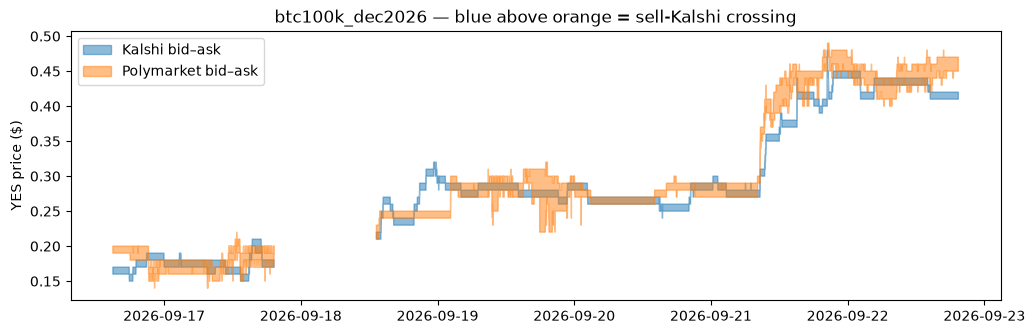

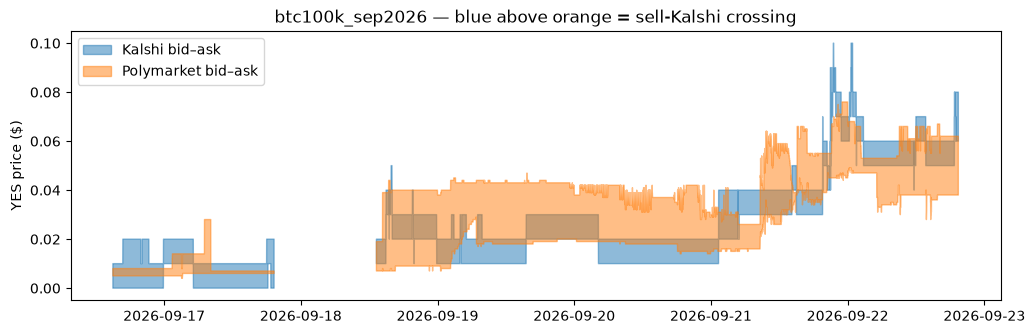

In [8]:
import matplotlib.pyplot as plt

def plot_bands(pair):
    r = (results[pair].set_index("ts")[["k_bid", "k_ask", "p_bid", "p_ask"]]
         .resample("1min").last())          # empty minutes (the outage) become gaps
    r.index = r.index.tz_convert(None)      # plain UTC times for the x-axis
    fig, ax = plt.subplots(figsize=(12, 3.5))
    ax.fill_between(r.index, r.k_bid, r.k_ask, color="tab:blue",   alpha=0.5, label="Kalshi bid–ask")
    ax.fill_between(r.index, r.p_bid, r.p_ask, color="tab:orange", alpha=0.5, label="Polymarket bid–ask")
    ax.set_title(pair + " — blue above orange = sell-Kalshi crossing")
    ax.set_ylabel("YES price ($)")
    ax.legend(loc="upper left")
    plt.show()

for p in ["btc100k_dec2026", "btc100k_sep2026"]:
    plot_bands(p)

In [9]:
d = q.sort_values(["pair_id", "venue", "ts"]).copy()
state = (d.best_bid.astype(str) + "|" + d.best_ask.astype(str) + "|"
         + d.bid_size.astype(str) + "|" + d.ask_size.astype(str))
d["new_run"] = ((state != state.shift())
                | (d.pair_id != d.pair_id.shift())
                | (d.venue != d.venue.shift())
                | (d.ts.diff() > pd.Timedelta("60s")))      # a collection gap also ends a run
d["run_id"] = d.new_run.cumsum()

runs = d.groupby(["pair_id", "venue", "run_id"]).ts.agg(start="min", end="max").reset_index()
runs["hours"] = ((runs.end - runs.start).dt.total_seconds() / 3600).round(2)

# longest stretch each book went completely unchanged (price AND size), per pair and venue
runs.loc[runs.groupby(["pair_id", "venue"]).hours.idxmax(), ["pair_id", "venue", "start", "end", "hours"]]

,pair_id,venue,start,end,hours
1682,btc100k_dec2026,kalshi,2026-09-20 06:41:45+00:00,2026-09-20 09:42:09+00:00,3.01
5843,btc100k_dec2026,poly,2026-09-20 18:04:32+00:00,2026-09-20 20:18:53+00:00,2.24
7765,btc100k_sep2026,kalshi,2026-09-17 05:12:37+00:00,2026-09-17 10:23:38+00:00,5.18
9016,btc100k_sep2026,poly,2026-09-17 08:12:58+00:00,2026-09-17 19:18:35+00:00,11.09
12664,elcrma_ELC,kalshi,2026-09-16 15:00:24+00:00,2026-09-17 13:42:19+00:00,22.70
12954,elcrma_ELC,poly,2026-09-15 20:25:46+00:00,2026-09-15 20:29:06+00:00,0.06
18779,elcrma_RMA,kalshi,2026-09-16 15:00:24+00:00,2026-09-17 13:42:19+00:00,22.70
19106,elcrma_RMA,poly,2026-09-15 20:23:06+00:00,2026-09-15 20:23:26+00:00,0.01
24902,elcrma_TIE,kalshi,2026-09-16 15:00:24+00:00,2026-09-17 13:42:19+00:00,22.70
24914,elcrma_TIE,poly,2026-09-15 18:38:24+00:00,2026-09-15 18:39:24+00:00,0.02


In [10]:
EQUIV = {"btc100k_dec2026": "poly_superset", "btc100k_sep2026": "poly_superset",
         "eth_sep_3000": "poly_superset",
         "fed_cuts_0": "equivalent", "fed_cuts_1": "equivalent", "fed_cuts_2": "equivalent"}

def episodes(m, gap="60s"):
    m = m.sort_values("ts")
    prof = m.net_exec > 0
    new_seg = m.ts.diff() > pd.Timedelta(gap)                 # collection gap ends an episode
    start = prof & (~prof.shift(fill_value=False) | new_seg)  # where each episode begins
    ep_id = start.cumsum().where(prof)                        # episode number, blank outside
    e = m[prof].groupby(ep_id[prof]).ts.agg(start="min", end="max", n="size")
    e["minutes"] = ((e.end - e.start).dt.total_seconds() + 20) / 60
    return e

rows = []
for p, m in results.items():
    e = episodes(m)
    if e.empty:
        continue
    rows.append({"pair": p, "class": EQUIV[p],
                 "episodes": len(e),
                 "single_obs_%": round((e.n == 1).mean() * 100, 1),
                 "median_min": round(e.minutes.median(), 1),
                 "max_min": round(e.minutes.max(), 1),
                 "time_in_10min+_%": round(e.n[e.minutes >= 10].sum() / e.n.sum() * 100, 1)})
pd.DataFrame(rows)

,pair,class,episodes,single_obs_%,median_min,max_min,time_in_10min+_%
0,btc100k_dec2026,poly_superset,43,32.6,1.0,326.5,93.0
1,btc100k_sep2026,poly_superset,26,46.2,0.7,215.7,95.5
2,eth_sep_3000,poly_superset,47,21.3,1.4,48.4,57.6
3,fed_cuts_0,equivalent,93,7.5,4.3,276.4,83.6
4,fed_cuts_1,equivalent,8,0.0,188.9,4884.8,99.9
5,fed_cuts_2,equivalent,261,31.4,0.7,1856.1,91.9


In [11]:
import numpy as np

def block_boot(m, block="30min", B=1000, seed=0):
    rng  = np.random.default_rng(seed)                    # fixed seed: same numbers every run
    key  = m.ts.dt.floor(block)                           # which block each row belongs to
    n    = m.groupby(key).size().to_numpy()
    cros = (m.gap_exec > 0).groupby(key).sum().to_numpy()
    prof = (m.net_exec > 0).groupby(key).sum().to_numpy()
    ann  = [g.ann_return[g.net_exec > 0].to_numpy() for _, g in m.groupby(key)]

    idx = rng.integers(0, len(n), size=(B, len(n)))       # B fake datasets of whole blocks
    cross_pct = cros[idx].sum(1) / n[idx].sum(1) * 100
    prof_pct  = prof[idx].sum(1) / n[idx].sum(1) * 100
    med_ann = []
    for row in idx:
        v = np.concatenate([ann[i] for i in row])
        med_ann.append(np.median(v) * 100 if len(v) else np.nan)
    return cross_pct, prof_pct, np.array(med_ann)

def fmt(est, draws):
    lo, hi = np.nanpercentile(draws, [2.5, 97.5])
    return f"{est:.2f}  [{lo:.2f}, {hi:.2f}]"

rows = []
for p, m in results.items():
    cr, pr, ma = block_boot(m)
    prof = m[m.net_exec > 0]
    rows.append({"pair": p, "class": EQUIV[p],
                 "crossing_%":   fmt((m.gap_exec > 0).mean() * 100, cr),
                 "profitable_%": fmt((m.net_exec > 0).mean() * 100, pr),
                 "median_ann_%": fmt(prof.ann_return.median() * 100, ma)})
pd.DataFrame(rows)

,pair,class,crossing_%,profitable_%,median_ann_%
0,btc100k_dec2026,poly_superset,"32.35 [27.29, 37.68]","7.89 [5.13, 11.00]","3.38 [2.16, 6.18]"
1,btc100k_sep2026,poly_superset,"9.38 [6.39, 12.59]","6.46 [3.89, 9.11]","1.34 [0.74, 3.12]"
2,eth_sep_3000,poly_superset,"16.65 [13.11, 20.31]","3.23 [1.66, 5.19]","8.53 [8.50, 19.82]"
3,fed_cuts_0,equivalent,"57.99 [52.21, 63.75]","21.55 [17.00, 26.52]","0.54 [0.49, 0.54]"
4,fed_cuts_1,equivalent,"99.64 [98.92, 100.00]","97.52 [95.19, 99.25]","5.27 [4.84, 5.68]"
5,fed_cuts_2,equivalent,"52.98 [46.59, 59.52]","52.98 [46.59, 59.52]","1.40 [1.09, 1.65]"


In [12]:
rows = []
for p, m in results.items():
    row = {"pair": p}
    for label, b in [("30 min", "30min"), ("2 h", "120min"), ("6 h", "360min")]:
        _, pr, _ = block_boot(m, block=b)
        row[label] = fmt((m.net_exec > 0).mean() * 100, pr)
    rows.append(row)
pd.DataFrame(rows)

,pair,30 min,2 h,6 h
0,btc100k_dec2026,"7.89 [5.13, 11.00]","7.89 [3.20, 13.34]","7.89 [2.75, 13.83]"
1,btc100k_sep2026,"6.46 [3.89, 9.11]","6.46 [2.38, 11.37]","6.46 [2.30, 11.24]"
2,eth_sep_3000,"3.23 [1.66, 5.19]","3.23 [0.87, 6.37]","3.23 [0.55, 7.29]"
3,fed_cuts_0,"21.55 [17.00, 26.52]","21.55 [13.36, 30.47]","21.55 [10.99, 32.77]"
4,fed_cuts_1,"97.52 [95.19, 99.25]","97.52 [93.03, 99.86]","97.52 [92.88, 100.00]"
5,fed_cuts_2,"52.98 [46.59, 59.52]","52.98 [41.78, 64.34]","52.98 [34.60, 71.29]"


In [13]:
CASH = 3.25   # ~% a year on idle cash

rows = []
for p, m in results.items():
    prof = m[m.net_exec > 0]
    days = prof.days.median()
    raw  = prof.net_exec / (1 - prof.gap_exec) * 100      # actual return, entry to resolution
    rows.append({"pair": p,
                 "days_held": round(days),
                 "median_raw_%": round(raw.median(), 3),
                 "cash_same_days_%": round(CASH * days / 365, 3),
                 "median_ann_%": round(prof.ann_return.median() * 100, 2)})
pd.DataFrame(rows)

,pair,days_held,median_raw_%,cash_same_days_%,median_ann_%
0,btc100k_dec2026,104,0.941,0.926,3.38
1,btc100k_sep2026,10,0.051,0.087,1.34
2,eth_sep_3000,13,0.309,0.118,8.53
3,fed_cuts_0,104,0.151,0.923,0.54
4,fed_cuts_1,102,1.486,0.912,5.27
5,fed_cuts_2,101,0.387,0.903,1.40


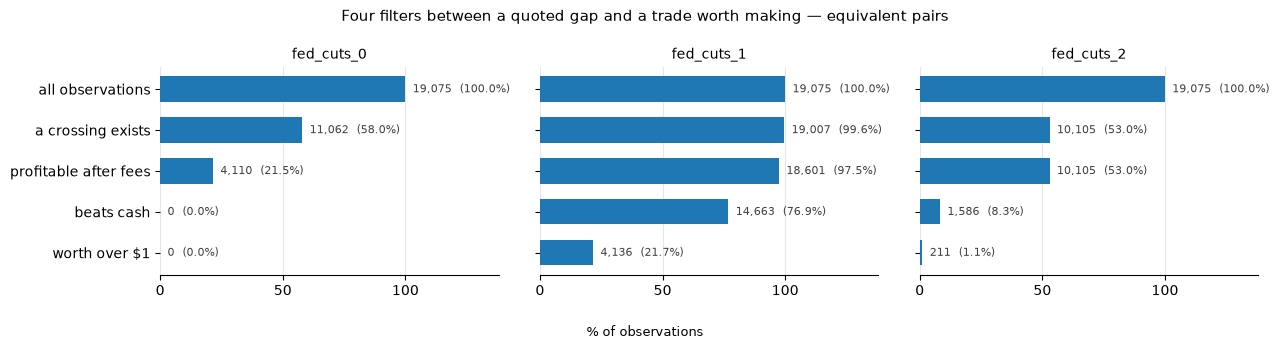

In [14]:
import matplotlib.pyplot as plt, os

CASH = 0.0325          # 3.25% a year on idle cash — the bar each trade has to clear
BLUE = "#1f77b4"
os.makedirs("figures", exist_ok=True)

def funnel_counts(pair):
    m = results[pair].merge(with_size(q, pair, PAIR_META[pair]["theta"])[["ts", "size", "profit_$"]],
                            on="ts", how="left")
    beats = (m.net_exec > 0) & (m.ann_return > CASH)
    return [("all observations",      len(m)),
            ("a crossing exists",     int((m.gap_exec > 0).sum())),
            ("profitable after fees", int((m.net_exec > 0).sum())),
            ("beats cash",            int(beats.sum())),
            ("worth over $1",         int((beats & (m["profit_$"] > 1)).sum()))]

pairs = ["fed_cuts_0", "fed_cuts_1", "fed_cuts_2"]        # the equivalent pairs
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), sharey=True)
for ax, p in zip(axes, pairs):
    labels, counts = zip(*funnel_counts(p))
    pct = [c / counts[0] * 100 for c in counts]
    ax.barh(range(len(counts)), pct, color=BLUE, height=0.62)
    ax.invert_yaxis(); ax.set_xlim(0, 138); ax.set_xticks([0, 50, 100])
    ax.set_title(p, fontsize=10)
    ax.xaxis.grid(True, color="0.9"); ax.set_axisbelow(True)
    for s in ["top", "right", "left"]:
        ax.spines[s].set_visible(False)
    for i, (c, v) in enumerate(zip(counts, pct)):
        ax.text(v + 3, i, f"{c:,}  ({v:.1f}%)", va="center", fontsize=8, color="0.25")

axes[0].set_yticks(range(5), labels)
fig.suptitle("Four filters between a quoted gap and a trade worth making — equivalent pairs", fontsize=11)
fig.supxlabel("% of observations", fontsize=9)
fig.tight_layout()
fig.savefig("figures/fig2_funnel.png", dpi=200, bbox_inches="tight")
plt.show()

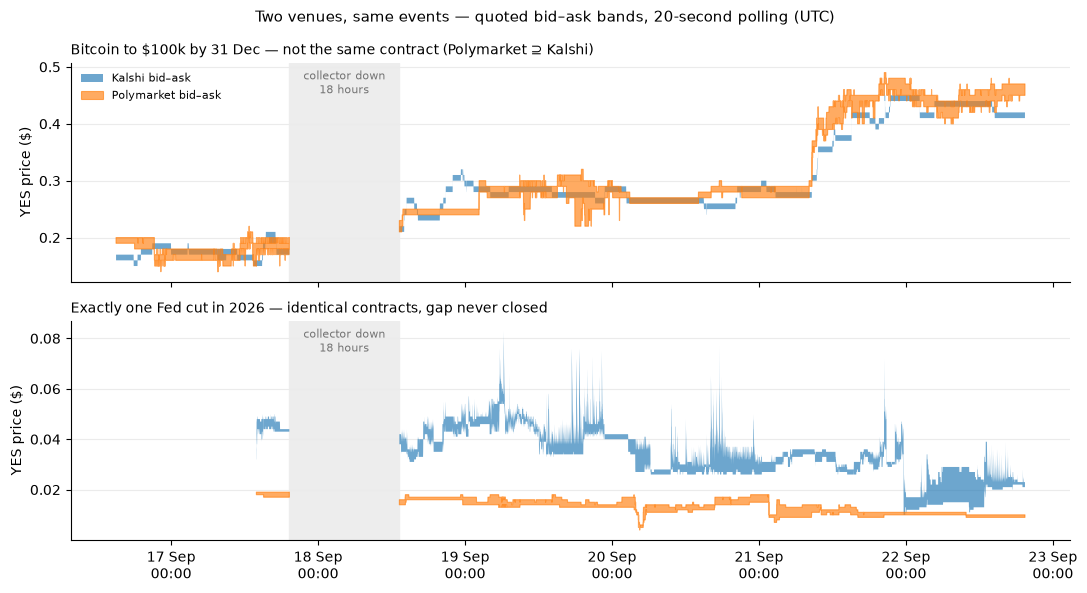

In [15]:
import matplotlib.dates as mdates

KAL, POLY = "#1f77b4", "#ff7f0e"
OUT0 = pd.Timestamp("2026-09-17 19:18")      # collector down, UTC
OUT1 = pd.Timestamp("2026-09-18 13:16")

def bands(ax, pair, title):
    r = (results[pair].set_index("ts")[["k_bid", "k_ask", "p_bid", "p_ask"]]
         .resample("1min").last())
    r.index = r.index.tz_convert(None)
    ax.axvspan(OUT0, OUT1, color="0.93", zorder=0)
    ax.annotate("collector down\n18 hours", xy=(OUT0 + (OUT1 - OUT0) / 2, 0.86),
                xycoords=("data", "axes fraction"), ha="center", fontsize=8, color="0.45")
    ax.fill_between(r.index, r.k_bid, r.k_ask, color=KAL, alpha=0.65, lw=0,
                    label="Kalshi bid–ask")
    ax.fill_between(r.index, r.p_bid, r.p_ask, color=POLY, alpha=0.65, lw=0.8,
                    edgecolor=POLY, label="Polymarket bid–ask")
    ax.set_title(title, fontsize=10, loc="left")
    ax.set_ylabel("YES price ($)")
    ax.yaxis.grid(True, color="0.92"); ax.set_axisbelow(True)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b\n%H:%M"))

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
bands(axes[0], "btc100k_dec2026",
      "Bitcoin to $100k by 31 Dec — not the same contract (Polymarket ⊇ Kalshi)")
bands(axes[1], "fed_cuts_1",
      "Exactly one Fed cut in 2026 — identical contracts, gap never closed")
axes[0].legend(loc="upper left", frameon=False, fontsize=8)
fig.suptitle("Two venues, same events — quoted bid–ask bands, 20-second polling (UTC)", fontsize=11)
fig.tight_layout()
fig.savefig("figures/fig1_price_bands.png", dpi=200, bbox_inches="tight")
plt.show()

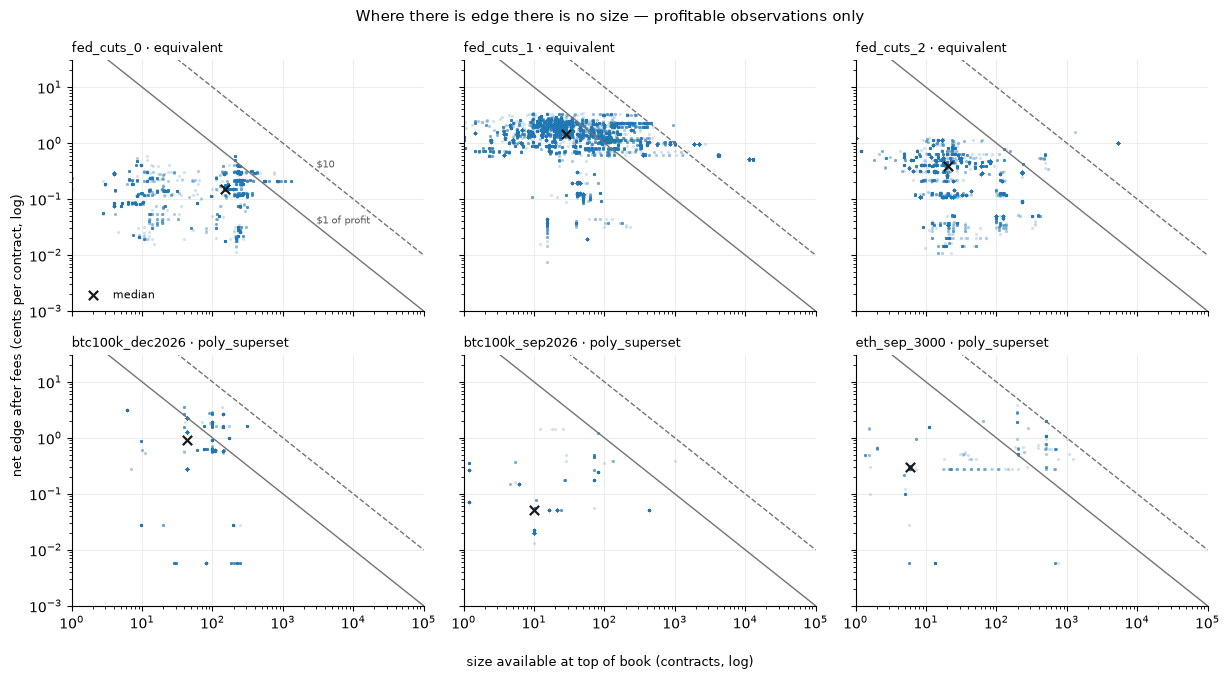

points below the chart floor: {'fed_cuts_0': 0, 'fed_cuts_1': 3, 'fed_cuts_2': 0, 'btc100k_dec2026': 0, 'btc100k_sep2026': 0, 'eth_sep_3000': 0}


In [16]:
order = ["fed_cuts_0", "fed_cuts_1", "fed_cuts_2",
         "btc100k_dec2026", "btc100k_sep2026", "eth_sep_3000"]

fig, axes = plt.subplots(2, 3, figsize=(12.5, 6.8), sharex=True, sharey=True)
xs = np.logspace(0, 5, 100)
offscale = {}
for ax, p in zip(axes.ravel(), order):
    w = with_size(q, p, PAIR_META[p]["theta"])
    w = w[w.net_exec > 0]
    y = w.net_exec * 100                                   # cents per contract
    offscale[p] = int((y < 1e-3).sum())
    ax.scatter(w["size"], y, s=5, alpha=0.20, color=BLUE, lw=0)
    ax.plot(xs, 100 / xs,  color="0.45", lw=1)             # $1 of profit
    ax.plot(xs, 1000 / xs, color="0.45", lw=1, ls="--")    # $10
    ax.scatter([w["size"].median()], [y.median()], marker="x", color="0.1", s=45, lw=1.6,
               zorder=5, label="median")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(1, 1e5); ax.set_ylim(1e-3, 30)
    ax.set_title(f"{p} · {EQUIV[p]}", fontsize=9, loc="left")
    ax.grid(color="0.93"); ax.set_axisbelow(True)
    for s_ in ["top", "right"]:
        ax.spines[s_].set_visible(False)

axes[0, 0].legend(frameon=False, fontsize=8, loc="lower left")
axes[0, 0].annotate("$1 of profit", xy=(3e3, 100 / 3e3),  fontsize=7, color="0.35", va="bottom")
axes[0, 0].annotate("$10",          xy=(3e3, 1000 / 3e3), fontsize=7, color="0.35", va="bottom")
fig.supxlabel("size available at top of book (contracts, log)", fontsize=9)
fig.supylabel("net edge after fees (cents per contract, log)", fontsize=9)
fig.suptitle("Where there is edge there is no size — profitable observations only", fontsize=11)
fig.tight_layout()
fig.savefig("figures/fig3_size_vs_edge.png", dpi=200, bbox_inches="tight")
plt.show()
print("points below the chart floor:", offscale)

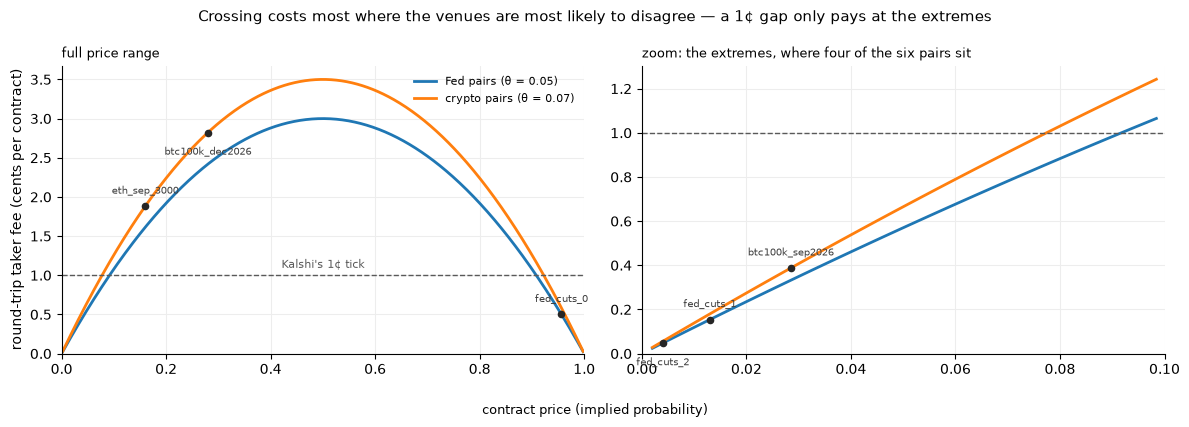

In [17]:
P = np.linspace(0.002, 0.998, 600)
def cost(x, theta): return (0.07 + theta) * x * (1 - x) * 100     # cents per contract, both venues

panels = [(0, 1, 0.10, 1.0, "full price range"),
          (0, 0.10, 0, 0.10, "zoom: the extremes, where four of the six pairs sit")]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, (lo, hi, llo, lhi, title) in zip(axes, panels):
    m = (P >= lo) & (P <= hi)
    ax.plot(P[m], cost(P[m], 0.05), color=KAL,  lw=2, label="Fed pairs (θ = 0.05)")
    ax.plot(P[m], cost(P[m], 0.07), color=POLY, lw=2, label="crypto pairs (θ = 0.07)")
    ax.axhline(1.0, color="0.35", lw=1, ls="--")
    ax.set_xlim(lo, hi); ax.set_ylim(0, None)
    ax.set_title(title, fontsize=9, loc="left")
    ax.grid(color="0.93"); ax.set_axisbelow(True)
    for s_ in ["top", "right"]:
        ax.spines[s_].set_visible(False)
    lab = [p for p in order if llo <= float(results[p].mid_p.median()) <= lhi]
    for i, p in enumerate(lab):
        x = float(results[p].mid_p.median())
        y = cost(x, PAIR_META[p]["theta"])
        ax.scatter([x], [y], color="0.15", s=20, zorder=5)
        ax.annotate(p, xy=(x, y), xytext=(0, 9 if i % 2 == 0 else -16),
                    textcoords="offset points", fontsize=7, color="0.25", ha="center")

axes[0].annotate("Kalshi's 1¢ tick", xy=(0.5, 1.06), fontsize=8, color="0.35", ha="center", va="bottom")
axes[0].legend(frameon=False, fontsize=8, loc="upper right")
axes[0].set_ylabel("round-trip taker fee (cents per contract)")
fig.supxlabel("contract price (implied probability)", fontsize=9)
fig.suptitle("Crossing costs most where the venues are most likely to disagree — a 1¢ gap only pays at the extremes",
             fontsize=11)
fig.tight_layout()
fig.savefig("figures/fig4_fee_breakeven.png", dpi=200, bbox_inches="tight")
plt.show()

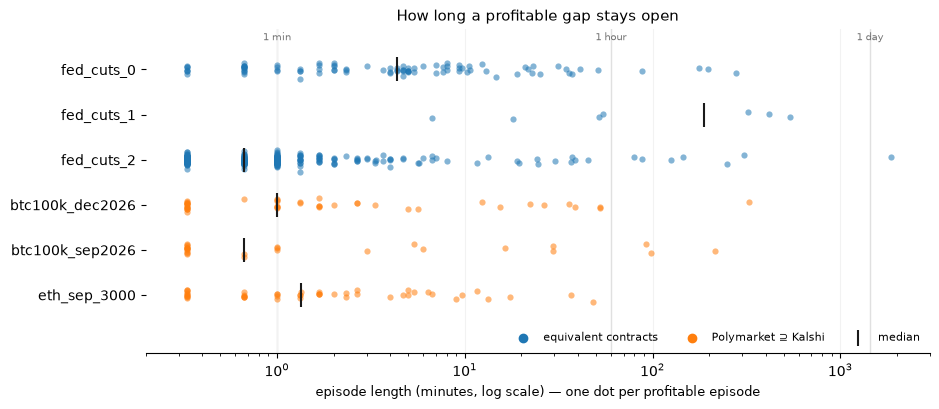

In [18]:
rng = np.random.default_rng(0)
rows = list(reversed(order))
fig, ax = plt.subplots(figsize=(9.5, 4.2))
for i, p in enumerate(rows):
    e = episodes(results[p])
    col = KAL if EQUIV[p] == "equivalent" else POLY
    y = i + rng.normal(0, 0.07, len(e))                     # jitter so dots don't stack
    ax.scatter(e.minutes, y, s=20, alpha=0.55, color=col, lw=0)
    ax.scatter([e.minutes.median()], [i], marker="|", s=300, color="0.1", zorder=5)

for x, lab in [(1, "1 min"), (60, "1 hour"), (1440, "1 day")]:
    ax.axvline(x, color="0.88", lw=1, zorder=0)
    ax.annotate(lab, xy=(x, len(rows) - 0.35), fontsize=7, color="0.45", ha="center")

ax.scatter([], [], color=KAL,  label="equivalent contracts")
ax.scatter([], [], color=POLY, label="Polymarket ⊇ Kalshi")
ax.scatter([], [], marker="|", s=120, color="0.1", label="median")
ax.legend(frameon=False, fontsize=8, loc="lower right", ncol=3)
ax.set_yticks(range(len(rows)), rows)
ax.set_xscale("log"); ax.set_xlim(0.2, 3000); ax.set_ylim(-1.3, len(rows) - 0.1)
ax.set_xlabel("episode length (minutes, log scale) — one dot per profitable episode", fontsize=9)
ax.xaxis.grid(True, color="0.95"); ax.set_axisbelow(True)
for s_ in ["top", "right", "left"]:
    ax.spines[s_].set_visible(False)
ax.set_title("How long a profitable gap stays open", fontsize=11)
fig.tight_layout()
fig.savefig("figures/fig5_episode_durations.png", dpi=200, bbox_inches="tight")
plt.show()

In [19]:
import sqlite3, io

out = io.StringIO()
def w(s=""): out.write(str(s) + "\n")

c = sqlite3.connect("crossvenue.db")
w(f"quotes rows: {c.execute('SELECT COUNT(*) FROM quotes').fetchone()[0]}")
w(f"book rows:   {c.execute('SELECT COUNT(*) FROM books').fetchone()[0]}")
h = pd.read_sql("SELECT ts, venue, pair_id FROM quotes", c)
h["ts"] = pd.to_datetime(h.ts)
h = h[h.pair_id.isin(PAIR_META)].sort_values(["pair_id", "venue", "ts"])
h["gap_min"] = h.groupby(["pair_id", "venue"]).ts.diff().dt.total_seconds() / 60
w("\nrows per pair and venue:")
w(h.groupby(["pair_id", "venue"]).agg(rows=("ts", "size"), first=("ts", "min"), last=("ts", "max")).to_string())
w("\ncollection gaps over 5 minutes:")
w(h[h.gap_min > 5][["pair_id", "venue", "ts", "gap_min"]].to_string(index=False))

CASH = 0.0325
for p, mm in PAIR_META.items():
    m = results[p]; prof = m[m.net_exec > 0]
    wz = with_size(q, p, mm["theta"]); wp = wz[wz.net_exec > 0]
    e = episodes(m); days = prof.days.median()
    w(f"\n== {p} ({EQUIV[p]}) n={len(m)} obs_hours={len(m)*20/3600:.1f} price={m.mid_p.median():.4f}")
    w(f"   crossing {(m.gap_exec>0).mean()*100:.1f}%  profitable {(m.net_exec>0).mean()*100:.1f}%  "
      f"beats cash {((m.net_exec>0)&(m.ann_return>CASH)).mean()*100:.1f}%  worth over $1 {(wp['profit_$']>1).mean()*100:.1f}%")
    w(f"   raw {(prof.net_exec/(1-prof.gap_exec)).median()*100:.3f}% over {days:.0f} days vs cash {3.25*days/365:.3f}%  |  "
      f"ann median {prof.ann_return.median()*100:.2f}% max {prof.ann_return.max()*100:.2f}%")
    w(f"   size median {wp['size'].median():.0f}  profit median ${wp['profit_$'].median():.2f}  max ${wp['profit_$'].max():.2f}  "
      f"sell-Kalshi direction {(prof.k_bid-prof.p_ask>0).mean()*100:.1f}%")
    w(f"   episodes {len(e)}  single-obs {(e.n==1).mean()*100:.1f}%  median {e.minutes.median():.1f} min  "
      f"max {e.minutes.max():.1f} min  in 10min+ {e.n[e.minutes>=10].sum()/e.n.sum()*100:.1f}%")

w("\n6-hour block bootstrap, estimate [95% interval]:")
for p, m in results.items():
    cr, pr, ma = block_boot(m, block="360min")
    w(f"   {p:16s} crossing {fmt((m.gap_exec>0).mean()*100, cr)} | profitable {fmt((m.net_exec>0).mean()*100, pr)} | "
      f"med ann {fmt(m[m.net_exec>0].ann_return.median()*100, ma)}")

w("\nfunnel counts:")
for p in ["fed_cuts_0", "fed_cuts_1", "fed_cuts_2"]:
    w(f"   {p}: {funnel_counts(p)}")

open("readme_numbers.txt", "w", encoding="utf-8").write(out.getvalue())
print(out.getvalue()[:600])
print("...\nwritten to readme_numbers.txt")

quotes rows: 280940
book rows:   1404288

rows per pair and venue:
                         rows                     first                      last
pair_id         venue                                                            
btc100k_dec2026 kalshi  23210 2026-09-16 15:00:24+00:00 2026-09-22 19:29:55+00:00
                poly    23465 2026-09-16 15:00:24+00:00 2026-09-22 19:29:55+00:00
btc100k_sep2026 kalshi  23210 2026-09-16 15:00:24+00:00 2026-09-22 19:29:55+00:00
                poly    23465 2026-09-16 15:00:24+00:00 2026-09-22 19:29:55+00:00
eth_sep_3000    kalshi  19086 2026-09-17 
...
written to readme_numbers.txt
